# 04a — Cheap Baseline Screen (single fold)

**This is a fast, single-fold first read on relative performance across candidate
feature sets and algorithms -- it is deliberately NOT the final, reportable 25-fold
(5x5 repeated CV) comparison.** Every model here is fit/evaluated on exactly one
held-out fold instead of all 25, so results are noisier and not to be quoted as final
numbers -- the point is only to catch gross problems (e.g. a feature set or algorithm
collapsing toward the naive floor) before committing to the expensive full comparison.

**Fold choice:** `repeat_0`, fold 0 (compounds where `repeat_0 == 0`) is the held-out
test set for this screen; the remaining folds (`repeat_0` in {1,2,3,4}) are pooled as
the training set. Fold 0 was picked as the first available option, not chosen after
looking at results.

**This notebook does:**
- Section 1: builds this screen's train/inner-val/test split (`src.features.
  assign_screen_split`) and documents per-isoform compound counts.
- Section 2: naive floor (`DummyRegressor` mean/median per isoform).
- Section 3: 9 tabular configs (3 feature sets x {RF, XGBoost, LightGBM}), run live
  inline (fast -- seconds per fit). TabICLv2 was dropped and log2fc_pretrained was
  removed -- see Section 3's markdown for both, neither is a modelling choice made
  silently.
- Section 4: loads (does not train) 10 Chemprop configs' predictions -- 5
  random-init (`scripts/run_baseline_screen_chemprop.py`, the fast stand-in used
  to unblock this screen) and 5 CheMeleon-init (`scripts/
  run_baseline_screen_chemprop_chemeleon.py`, the project's real architecture, at
  its real measured cost) -- both kept, clearly labeled, for direct comparison.
- Section 5: bootstrapped metrics (ST-RAE, MAE, R2, Spearman, Kendall's tau; 1000
  resamples), reusing the vendored OpenADMET evaluation code directly.
- Section 6: heatmap + per-metric error-bar visualizations.
- Section 7: CLAUDE.md compliance checklist.

No promotion threshold for the 25-fold comparison is computed or suggested anywhere in
this notebook -- that's explicitly deferred until these results exist and can be looked
at directly.

In [14]:
# rdkit and torch have each been known to bundle their own conflicting OpenMP runtime
# on this machine (documented in `src/features.py` / `scripts/train_log2fc_encoder.py`
# -- both must never be imported into the same process without this set first); XGBoost
# and LightGBM also use OpenMP internally. Set globally, before any of those imports,
# to be safe rather than scoping it to just one library.
import os

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

'TRUE'

In [15]:
import importlib.metadata
import json
import sys
import time
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))  # so `from src... import ...` works regardless of cwd

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from src.features import assign_screen_split
from src.vendor.openadmet_eval.config import ACTIVITY_METRICS, BOOTSTRAP_SAMPLES, REGRESSION_ENDPOINTS
from src.vendor.openadmet_eval.evaluate_predictions import add_macro_endpoint, score_activity_predictions

FOLDS = REPO_ROOT / "data" / "folds"
PROCESSED = REPO_ROOT / "data" / "processed"
OUTPUTS = REPO_ROOT / "outputs" / "04a_baseline_screen"
PREDICTIONS = OUTPUTS / "predictions"
PARAMS = OUTPUTS / "params"
PREDICTIONS.mkdir(parents=True, exist_ok=True)
PARAMS.mkdir(parents=True, exist_ok=True)

SEED = 42
REPEAT_COL = "repeat_0"
TEST_FOLD = 0
VAL_FRACTION = 0.15
XGB_LGBM_EARLY_STOPPING_ROUNDS = 10  # confirmed with the user -- see notebook markdown

ISOFORM_SHORT_NAMES = [endpoint.split("_")[0] for endpoint in REGRESSION_ENDPOINTS]

print(f"python: {sys.version.split()[0]}")
for pkg in ["numpy", "pandas", "scikit-learn", "xgboost", "lightgbm"]:
    print(f"{pkg}: {importlib.metadata.version(pkg)}")
print(f"OMP_NUM_THREADS={os.environ.get('OMP_NUM_THREADS')}")
print(f"SEED = {SEED}")
print(f"screen fold: {REPEAT_COL} == {TEST_FOLD} held out as screen_test; inner val fraction = {VAL_FRACTION}")

python: 3.11.13
numpy: 1.26.4
pandas: 2.3.3
scikit-learn: 1.9.0
xgboost: 3.2.0
lightgbm: 4.7.0
OMP_NUM_THREADS=1
SEED = 42
screen fold: repeat_0 == 0 held out as screen_test; inner val fraction = 0.15


## 1. Screen split and per-isoform compound counts

`assign_screen_split` (`src/features.py`) is the one shared function that produces this
screen's `screen_test` / `screen_inner_train` / `screen_inner_val` assignment -- called
identically (same arguments) from this notebook and from
`scripts/run_baseline_screen_chemprop.py`, so both processes see a byte-identical split
without needing to freeze an intermediate file (cross-checked directly in Section 4).

`screen_inner_val` (15% of the pooled training side) is the validation split for any
configuration capable of early stopping (XGBoost, LightGBM, both Chemprop variants) --
carved from the training side only, never touching `screen_test`. RF has no
early-stopping concept and fits on `screen_inner_train` + `screen_inner_val` pooled
back together.

In [16]:
cv_folds = pd.read_csv(FOLDS / "cv_folds.csv")
curated = pd.read_csv(PROCESSED / "train_inhibition_curated.csv")
print(f"loaded cv_folds.csv: {cv_folds.shape}")
print(f"loaded train_inhibition_curated.csv: {curated.shape}")

split_df = assign_screen_split(
    cv_folds, repeat_col=REPEAT_COL, test_fold=TEST_FOLD, val_fraction=VAL_FRACTION, seed=SEED
)
print(f"assign_screen_split counts: {split_df['screen_split'].value_counts().to_dict()}")

population = split_df.merge(curated, on=["Molecule_Name", "inchikey"], how="left")
assert len(population) == len(split_df) and population["canonical_smiles"].notna().all()
print(f"rows after joining curated labels: {len(population)} (missing: 0)")

loaded cv_folds.csv: (4905, 7)
loaded train_inhibition_curated.csv: (4905, 20)
assign_screen_split counts: {'screen_inner_train': 3335, 'screen_test': 981, 'screen_inner_val': 589}
rows after joining curated labels: 4905 (missing: 0)


In [17]:
def isoform_counts(pop: pd.DataFrame, endpoint: str) -> dict:
    labeled = pop[pop[endpoint].notna()]
    return labeled.groupby("screen_split").size().reindex(
        ["screen_inner_train", "screen_inner_val", "screen_test"], fill_value=0
    ).to_dict()


counts_table = pd.DataFrame(
    {endpoint: isoform_counts(population, endpoint) for endpoint in REGRESSION_ENDPOINTS}
).T
counts_table["total"] = counts_table.sum(axis=1)
counts_table

,screen_inner_train,screen_inner_val,screen_test,total
CYP1A2_pIC50_direct_inhibition,969,166,277,1412
CYP2C9_pIC50_direct_inhibition,858,163,264,1285
CYP2D6_pIC50_direct_inhibition,1024,174,295,1493
CYP3A4_pIC50_direct_inhibition,1612,273,450,2335


**What this shows:** per-isoform compound counts in each of this screen's three
buckets. Row totals should match the known per-isoform totals from notebook 01/03
(CYP1A2 1,412 / CYP2C9 1,285 / CYP2D6 1,493 / CYP3A4 2,335) -- confirmed by construction
here since `assign_screen_split` partitions the full 4,905-compound training set with no
compound dropped. `screen_test` counts (not `screen_inner_train`+`screen_inner_val`) are
the population every configuration below is actually scored against per isoform.

## 2. Naive floor

`DummyRegressor` (`strategy="mean"` and `"median"`) per isoform, fit on this screen's
full pooled training side (`screen_inner_train` + `screen_inner_val` -- no inner split
needed, there's nothing to early-stop), predicting on every `screen_test` compound.
Reported alongside the 21 real configurations below, not counted as one of them --
these two never see `screen_test` labels during fitting.

In [18]:
def isoform_pool_train(pop: pd.DataFrame, endpoint: str) -> pd.DataFrame:
    pool_mask = pop["screen_split"].isin(["screen_inner_train", "screen_inner_val"])
    return pop.loc[pool_mask & pop[endpoint].notna()]


test_ids = population.loc[population["screen_split"] == "screen_test", ["Molecule_Name", "inchikey"]].reset_index(drop=True)
print(f"screen_test compounds: {len(test_ids)}")

for strategy in ["mean", "median"]:
    pred_df = test_ids.copy()
    params_record = {"config": f"naive_{strategy}", "strategy": strategy, "per_isoform": {}}
    for endpoint in REGRESSION_ENDPOINTS:
        train_rows = isoform_pool_train(population, endpoint)
        model = DummyRegressor(strategy=strategy)
        model.fit(np.zeros((len(train_rows), 1)), train_rows[endpoint].to_numpy())
        pred_df[endpoint] = model.predict(np.zeros((len(test_ids), 1)))
        params_record["per_isoform"][endpoint] = {"n_pool_train": len(train_rows), "constant": float(model.constant_[0][0])}

    pred_path = PREDICTIONS / f"naive_{strategy}.csv"
    pred_df.to_csv(pred_path, index=False)
    with open(PARAMS / f"naive_{strategy}.json", "w") as f:
        json.dump(params_record, f, indent=2)
    print(f"wrote {pred_path}")

screen_test compounds: 981
wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/04a_baseline_screen/predictions/naive_mean.csv
wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/04a_baseline_screen/predictions/naive_median.csv


## 3. Tabular configs (9 = 3 feature sets x 3 algorithms)

Library default hyperparameters throughout -- no inner hyperparameter search at this
stage (deferred to the full 25-fold comparison). Each "configuration" is 4 independent
per-isoform single-output models (the natural default for RF/XGBoost/LightGBM, all
single-output regressors by default), reported together as one row spanning all 4
isoforms.

**`log2fc_pretrained` removed from this screen -- a framing correction, not a
result.** It was previously run here as a fourth competing feature set alongside
`tabular_baseline`/`tabular_rdkit2d`/`chemeleon`. That was the wrong framing:
`log2fc_pretrained` is meant to be tested later as an *add-on* to whichever feature
set wins this baseline screen (concatenated onto the winner's feature matrix,
compared with-vs-without -- the same way the planned RDKit logD/HOMO-LUMO
auxiliary features are meant to be tested against Chemprop's learned
representation), not as a rival core feature set in its own right. A leakage check
was drafted for it (`scripts/train_log2fc_encoder_blind.py` -- its encoder was
pretrained on the full 4,376-compound primary-screen set, which includes compounds
now in `screen_test`, so the feature may carry test-compound information into any
screen that uses it) -- that check is paused, not abandoned: it applies once the
actual ablation (winner + log2fc vs. winner alone) happens later, not to this
baseline comparison.

**TabICLv2 was dropped from this screen -- a verified hardware constraint, not a
modelling choice.** At its library-default settings (`n_estimators=8`), a single
`.predict()` call over this screen's ~3,924-compound training context tried to
allocate 36-50GB (confirmed via a clean `RuntimeError: MPS backend out of memory`
message when forced onto the Apple GPU) against this machine's 36GB of RAM -- the CPU
path hits the identical wall silently (`SIGKILL`, exit code 137, no Python traceback).
This scaled with feature-set width: the two ~2,000+-dim feature sets
(`tabular_baseline`, `chemeleon`) are outright infeasible; even the two low-dimensional
sets tested at the time (`tabular_rdkit2d` 217-dim, `log2fc_pretrained` 300-dim --
the latter has since been reframed out of this screen, see above) took 4+ minutes
for a single isoform's `.predict()` call on CPU. Forcing the Apple GPU (MPS) instead of
working around the memory ceiling **segfaults** outright (exit code 139) even at
217 dimensions -- consistent with this project's already-documented pattern of MPS
being unreliable for this ML stack (the same reason Chemprop is kept CPU-only). A
smaller ensemble (`n_estimators=1`) was confirmed to avoid the crash but was not
adopted, since it would silently violate the "library default hyperparameters"
instruction for this screen -- raised with the user directly instead, who chose to
drop TabICLv2 entirely for this run rather than deviate from library defaults or
partially cover it. Revisit on a machine that can run it at real defaults, not by
quietly substituting different hyperparameters here.

- **RF** (no early-stopping concept): fit on the full pooled training side
  (`screen_inner_train` + `screen_inner_val`, isoform-labeled).
- **XGBoost**: `early_stopping_rounds=10` passed as a constructor argument (XGBoost
  >=1.6 -- the already-known fix, not the practice-repo bug where this was a `.fit()`
  kwarg) with `eval_set` given in `.fit()`.
- **LightGBM**: `early_stopping_rounds` is *not* a valid `.fit()`/constructor kwarg in
  this LightGBM version (4.7.0, verified directly) -- uses
  `callbacks=[lightgbm.early_stopping(stopping_rounds=10)]` instead, the correct
  modern API.
- Both boosting libraries: `early_stopping_rounds`/`stopping_rounds` = 10, against each
  library's own default `n_estimators=100` -- confirmed with the user (chemprop's own
  `--patience` uses a different, epoch-scale number; see the Chemprop script).

Predictions are always computed for every `screen_test` compound's features regardless
of that compound's per-isoform label availability -- scoring (Section 5) naturally
restricts to the labeled subset per isoform via ground-truth NaN masking, so this
decoupling needs no special-casing here.

In [19]:
FEATURE_FILES = {
    "tabular_baseline": "tabular_baseline_features.csv",
    "tabular_rdkit2d": "tabular_baseline_features_rdkit2d.csv",
    "chemeleon": "chemeleon_embeddings.npy",
}


def load_feature_matrix(name: str):
    path = PROCESSED / FEATURE_FILES[name]
    if path.suffix == ".csv":
        df = pd.read_csv(path)
        index_df = df[["Molecule_Name", "inchikey", "split"]].reset_index(drop=True)
        X = df.drop(columns=["Molecule_Name", "inchikey", "split"]).to_numpy(dtype=np.float64)
    else:
        X = np.load(path)
        index_df = pd.read_csv(path.with_name(f"{path.stem}_index.csv")).reset_index(drop=True)
    return index_df, X


# Row order is identical across all feature sources (verified during planning), so
# one position index (built from any one of them) is valid for indexing into any of
# the X matrices -- computed once here rather than per feature set.
_feat_index, _ = load_feature_matrix("tabular_baseline")
pop_pos = _feat_index.reset_index().merge(population, on=["Molecule_Name", "inchikey"], how="left")
INNER_TRAIN_MASK = pop_pos["screen_split"] == "screen_inner_train"
INNER_VAL_MASK = pop_pos["screen_split"] == "screen_inner_val"
POOL_MASK = pop_pos["screen_split"].isin(["screen_inner_train", "screen_inner_val"])
TEST_MASK = pop_pos["screen_split"] == "screen_test"
TEST_POSITIONS = pop_pos.loc[TEST_MASK, "index"].to_numpy()
assert (pop_pos.loc[TEST_MASK, ["Molecule_Name", "inchikey"]].reset_index(drop=True) == test_ids).all().all()
print(f"pop_pos: {pop_pos.shape}, screen_test positions: {len(TEST_POSITIONS)}")

pop_pos: (5655, 23), screen_test positions: 981


In [20]:
def fit_predict_isoform(algo: str, X: np.ndarray, endpoint: str, seed: int = SEED):
    has_label = pop_pos[endpoint].notna()
    if algo == "rf":
        pool_idx = pop_pos.loc[POOL_MASK & has_label, "index"].to_numpy()
        y_pool = pop_pos.loc[POOL_MASK & has_label, endpoint].to_numpy()
        model = RandomForestRegressor(random_state=seed)
        model.fit(X[pool_idx], y_pool)
    elif algo in ("xgboost", "lightgbm"):
        tr_idx = pop_pos.loc[INNER_TRAIN_MASK & has_label, "index"].to_numpy()
        va_idx = pop_pos.loc[INNER_VAL_MASK & has_label, "index"].to_numpy()
        y_tr = pop_pos.loc[INNER_TRAIN_MASK & has_label, endpoint].to_numpy()
        y_va = pop_pos.loc[INNER_VAL_MASK & has_label, endpoint].to_numpy()
        if algo == "xgboost":
            model = XGBRegressor(early_stopping_rounds=XGB_LGBM_EARLY_STOPPING_ROUNDS, random_state=seed)
            model.fit(X[tr_idx], y_tr, eval_set=[(X[va_idx], y_va)], verbose=False)
        else:
            model = LGBMRegressor(random_state=seed, verbosity=-1)
            model.fit(
                X[tr_idx], y_tr, eval_set=[(X[va_idx], y_va)],
                callbacks=[lgb.early_stopping(stopping_rounds=XGB_LGBM_EARLY_STOPPING_ROUNDS, verbose=False)],
            )
    else:
        raise ValueError(f"unknown algorithm: {algo}")
    preds = model.predict(X[TEST_POSITIONS])
    return np.asarray(preds).reshape(-1), model


def run_tabular_config(feature_name: str, algo_name: str, X: np.ndarray) -> str:
    config_name = f"{feature_name}__{algo_name}"
    pred_df = test_ids.copy()
    params_record = {
        "config": config_name, "feature_set": FEATURE_FILES[feature_name],
        "algorithm": algo_name, "seed": SEED, "per_isoform_params": {},
    }
    for endpoint in REGRESSION_ENDPOINTS:
        preds, model = fit_predict_isoform(algo_name, X, endpoint)
        pred_df[endpoint] = preds
        params_record["per_isoform_params"][endpoint] = model.get_params()

    pred_path = PREDICTIONS / f"{config_name}.csv"
    pred_df.to_csv(pred_path, index=False)
    with open(PARAMS / f"{config_name}.json", "w") as f:
        json.dump(params_record, f, indent=2, default=str)
    print(f"wrote {pred_path}")
    return config_name

In [21]:
TABULAR_CONFIG_NAMES = []
for feature_name in FEATURE_FILES:
    _, X = load_feature_matrix(feature_name)
    for algo_name in ["rf", "xgboost", "lightgbm"]:
        t0 = time.time()
        name = run_tabular_config(feature_name, algo_name, X)
        TABULAR_CONFIG_NAMES.append(name)
        print(f"  ({time.time() - t0:.1f}s)")

print(f"\ncompleted {len(TABULAR_CONFIG_NAMES)} tabular configs")

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/04a_baseline_screen/predictions/tabular_baseline__rf.csv
  (34.3s)
wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/04a_baseline_screen/predictions/tabular_baseline__xgboost.csv
  (0.8s)


/opt/anaconda3/envs/cyp-admet/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/opt/anaconda3/envs/cyp-admet/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/opt/anaconda3/envs/cyp-admet/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/opt/anaconda3/envs/cyp-admet/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _va

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/04a_baseline_screen/predictions/tabular_baseline__lightgbm.csv
  (0.7s)
wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/04a_baseline_screen/predictions/tabular_rdkit2d__rf.csv
  (18.9s)
wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/04a_baseline_screen/predictions/tabular_rdkit2d__xgboost.csv
  (0.8s)


/opt/anaconda3/envs/cyp-admet/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/opt/anaconda3/envs/cyp-admet/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/opt/anaconda3/envs/cyp-admet/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/opt/anaconda3/envs/cyp-admet/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _va

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/04a_baseline_screen/predictions/tabular_rdkit2d__lightgbm.csv
  (0.8s)
wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/04a_baseline_screen/predictions/chemeleon__rf.csv
  (212.3s)
wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/04a_baseline_screen/predictions/chemeleon__xgboost.csv
  (19.6s)


/opt/anaconda3/envs/cyp-admet/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/opt/anaconda3/envs/cyp-admet/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/opt/anaconda3/envs/cyp-admet/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/opt/anaconda3/envs/cyp-admet/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _va

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/04a_baseline_screen/predictions/chemeleon__lightgbm.csv
  (4.7s)

completed 9 tabular configs


**What this produced:** one wide predictions CSV + params JSON per tabular config
(9 total) in `outputs/04a_baseline_screen/predictions/` and `.../params/`, saved
immediately after each config's 4 isoform fits complete -- so nothing here depends on
re-running this notebook from scratch.

## 4. Load Chemprop results (not trained here)

Two Chemprop variants are compared here, side by side -- both loaded (not trained)
from their own standalone scripts' output, per this project's established convention
(`train_log2fc_encoder.py`); neither runs inside this notebook or an agentic session:

- **Random-init** (`_randominit` below) -- the fast stand-in originally used to unblock
  this cheap screen, since CheMeleon-init alone (see below) was infeasible at the time.
  `scripts/run_baseline_screen_chemprop.py`:
  ```
  cd /path/to/OpenADMET-CYP-Blind-Challenge
  caffeinate -i nohup python scripts/run_baseline_screen_chemprop.py > /dev/null 2>&1 &
  ```
- **CheMeleon-init** (`_chemeleoninit` below) -- the real architecture the project's
  actual plan (the full 25-fold comparison) uses, now included here too, at its real
  measured cost (expect multiple hours -- an overnight run is expected, see that
  script's own docstring). `scripts/run_baseline_screen_chemprop_chemeleon.py`:
  ```
  cd /path/to/OpenADMET-CYP-Blind-Challenge
  caffeinate -i nohup python scripts/run_baseline_screen_chemprop_chemeleon.py > \
      logs/04a_chemprop_chemeleon_stdout.log 2>&1 &
  ```

This section only loads both scripts' output prediction files -- if either is missing,
run its command above first (progress: `tail -f logs/04a_chemprop_screen.log` for
random-init, `tail -f logs/04a_chemprop_screen_chemeleon.log` for CheMeleon-init).

**Why both exist, stated plainly.** CheMeleon's checkpoint forces the message-passing
encoder to its own real architecture (2048-wide, 8.7M params) regardless of
`--epochs`/`--patience` -- measured directly at ~2:47/epoch for single-task CYP1A2, a
~13x slowdown against 03b's benchmarked ~13s/epoch for the same-sized random-init
network. Random-init unblocked this screen quickly and cheaply; CheMeleon-init is the
architecture the project's actual plan uses and is now run here too, once, at its real
cost, specifically so the two can be compared directly (Section 6) rather than one
being assumed from the other. Both share the identical `assign_screen_split` call,
`--epochs 50`/`--patience 5`/`--data-seed 42`/`--pytorch-seed 42`, and the same shared
orchestration code (`src/chemprop_screen.py`) -- only the encoder's
initialization/architecture differs between the two scripts.

In [22]:
CHEMPROP_CONFIGS = {}
for short, endpoint in zip(ISOFORM_SHORT_NAMES, REGRESSION_ENDPOINTS):
    CHEMPROP_CONFIGS[f"chemprop_singletask_{short}_randominit"] = {
        "file": f"chemprop_singletask_{short}.csv", "endpoints": [endpoint],
    }
    CHEMPROP_CONFIGS[f"chemprop_singletask_{short}_chemeleoninit"] = {
        "file": f"chemprop_chemeleon_singletask_{short}.csv", "endpoints": [endpoint],
    }
CHEMPROP_CONFIGS["chemprop_multitask_randominit"] = {
    "file": "chemprop_multitask.csv", "endpoints": list(REGRESSION_ENDPOINTS),
}
CHEMPROP_CONFIGS["chemprop_multitask_chemeleoninit"] = {
    "file": "chemprop_chemeleon_multitask.csv", "endpoints": list(REGRESSION_ENDPOINTS),
}

chemprop_predictions = {}
missing = [spec["file"] for spec in CHEMPROP_CONFIGS.values() if not (PREDICTIONS / spec["file"]).exists()]
if missing:
    raise FileNotFoundError(
        f"missing Chemprop prediction file(s): {missing} -- run the random-init and/or "
        "CheMeleon-init launch commands above first, then re-run this section "
        "(tail -f logs/04a_chemprop_screen.log or "
        "tail -f logs/04a_chemprop_screen_chemeleon.log to watch progress)."
    )

for name, spec in CHEMPROP_CONFIGS.items():
    df = pd.read_csv(PREDICTIONS / spec["file"])
    assert set(df["Molecule_Name"]) == set(test_ids["Molecule_Name"]), (
        f"{name}: Molecule_Name set does not match this notebook's own screen_test set -- "
        "split determinism between this notebook and the script did not hold."
    )
    chemprop_predictions[name] = df
    print(f"loaded {spec['file']} as {name}: {df.shape}")

print("\nsplit-determinism cross-check passed: both scripts' independently-computed "
      "assign_screen_split calls produced an identical screen_test set to this notebook's own.")

loaded chemprop_singletask_CYP1A2.csv as chemprop_singletask_CYP1A2_randominit: (981, 4)
loaded chemprop_chemeleon_singletask_CYP1A2.csv as chemprop_singletask_CYP1A2_chemeleoninit: (981, 4)
loaded chemprop_singletask_CYP2C9.csv as chemprop_singletask_CYP2C9_randominit: (981, 4)
loaded chemprop_chemeleon_singletask_CYP2C9.csv as chemprop_singletask_CYP2C9_chemeleoninit: (981, 4)
loaded chemprop_singletask_CYP2D6.csv as chemprop_singletask_CYP2D6_randominit: (981, 4)
loaded chemprop_chemeleon_singletask_CYP2D6.csv as chemprop_singletask_CYP2D6_chemeleoninit: (981, 4)
loaded chemprop_singletask_CYP3A4.csv as chemprop_singletask_CYP3A4_randominit: (981, 4)
loaded chemprop_chemeleon_singletask_CYP3A4.csv as chemprop_singletask_CYP3A4_chemeleoninit: (981, 4)
loaded chemprop_multitask.csv as chemprop_multitask_randominit: (981, 7)
loaded chemprop_chemeleon_multitask.csv as chemprop_multitask_chemeleoninit: (981, 7)

split-determinism cross-check passed: both scripts' independently-computed a

## 5. Bootstrapped metrics (vendored code, reused directly)

`score_activity_predictions` + `add_macro_endpoint`
(`src/vendor/openadmet_eval/evaluate_predictions.py`) already implement everything
needed here -- 1000-resample bootstrapping (`BOOTSTRAP_SAMPLES`), the soft-thresholded
RAE metric with credible-interval bounds, and plain-mean macro-averaging across
endpoints -- so none of it is reimplemented. Each of the 21 configs (19 real + 2 naive)
is scored exactly as if it were one leaderboard submission: `ground_truth` is the
`screen_test` subset of `train_inhibition_curated.csv` (already carrying the
`_conf_high`/`_conf_low` columns ST-RAE needs), and `predictions` is that config's own
wide CSV. Each single-task Chemprop config only ever produced one real isoform column,
so it's scored against just that one endpoint (no macro "MA" row is meaningful, or
computed, for a length-1 endpoint list) -- every other config is scored against all 4.

In [23]:
ground_truth = curated[curated["inchikey"].isin(test_ids["inchikey"])].copy()
print(f"ground_truth (screen_test rows of train_inhibition_curated.csv): {ground_truth.shape}")

ALL_CONFIGS = {}
for name in ["naive_mean", "naive_median", *TABULAR_CONFIG_NAMES]:
    ALL_CONFIGS[name] = {"predictions": pd.read_csv(PREDICTIONS / f"{name}.csv"), "endpoints": list(REGRESSION_ENDPOINTS)}
for name, spec in CHEMPROP_CONFIGS.items():
    ALL_CONFIGS[name] = {"predictions": chemprop_predictions[name], "endpoints": spec["endpoints"]}

print(f"total configs to score: {len(ALL_CONFIGS)}")
assert len(ALL_CONFIGS) == 2 + 9 + 10 == 21

ground_truth (screen_test rows of train_inhibition_curated.csv): (981, 20)
total configs to score: 21


In [24]:
all_bootstrap_results = []
for config_name, spec in ALL_CONFIGS.items():
    scored = score_activity_predictions(spec["predictions"], ground_truth, spec["endpoints"])
    scored = add_macro_endpoint(scored, spec["endpoints"], ACTIVITY_METRICS)
    scored["config"] = config_name
    all_bootstrap_results.append(scored)

bootstrap_df = pd.concat(all_bootstrap_results, ignore_index=True)
bootstrap_path = OUTPUTS / "bootstrap_metrics_all_configs.csv"
bootstrap_df.to_csv(bootstrap_path, index=False)
print(f"wrote {bootstrap_path}: {bootstrap_df.shape}")

METRIC_NAMES = [name for name, _ in ACTIVITY_METRICS]
summary = (
    bootstrap_df.groupby(["config", "Endpoint"])[METRIC_NAMES]
    .agg(["mean", lambda s: s.quantile(0.025), lambda s: s.quantile(0.975)])
)
summary.columns = [f"{metric}_{stat}" for metric, stat in
                   zip([m for m in METRIC_NAMES for _ in range(3)], ["mean", "ci_low", "ci_high"] * len(METRIC_NAMES))]
summary = summary.reset_index()
summary_path = OUTPUTS / "summary_table.csv"
summary.to_csv(summary_path, index=False)
print(f"wrote {summary_path}: {summary.shape}")
summary.head()

2026-08-25 09:24:01.564 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth
2026-08-25 09:24:01.567 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 25 columns.
2026-08-25 09:24:01.568 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition
2026-08-25 09:24:01.568 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 704 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition
/Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/src/vendor/openadmet_eval/evaluate_predictions.py:421: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  metric_value = metric_func(y_true[idx], y_pre

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/04a_baseline_screen/bootstrap_metrics_all_configs.csv: (73000, 8)
wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/04a_baseline_screen/summary_table.csv: (73, 17)


,config,Endpoint,ST-RAE_mean,ST-RAE_ci_low,ST-RAE_ci_high,MAE_mean,MAE_ci_low,MAE_ci_high,R2_mean,R2_ci_low,R2_ci_high,Spearman_R_mean,Spearman_R_ci_low,Spearman_R_ci_high,Kendall_Tau_mean,Kendall_Tau_ci_low,Kendall_Tau_ci_high
0,chemeleon__lightgbm,CYP1A2_pIC50_direct_inhibition,0.881875,0.784662,0.985027,0.718622,0.650358,0.790379,0.187800,0.086709,0.275022,0.426128,0.330158,0.523138,0.293883,0.224853,0.365278
1,chemeleon__lightgbm,CYP2C9_pIC50_direct_inhibition,0.806580,0.716079,0.907477,0.579656,0.521933,0.634663,0.242026,0.158509,0.324526,0.478739,0.382299,0.568271,0.334121,0.265342,0.401995
2,chemeleon__lightgbm,CYP2D6_pIC50_direct_inhibition,0.912592,0.848421,0.976981,0.574319,0.508046,0.647896,0.147305,0.073890,0.213993,0.419049,0.325936,0.515922,0.288641,0.223586,0.357921
3,chemeleon__lightgbm,CYP3A4_pIC50_direct_inhibition,0.629449,0.560109,0.699184,0.619667,0.573330,0.665451,0.471376,0.403751,0.531850,0.685717,0.634102,0.733127,0.494445,0.452172,0.533758
4,chemeleon__lightgbm,MA,0.807624,0.764801,0.851585,0.623066,0.589239,0.653995,0.262127,0.220754,0.298351,0.502408,0.457597,0.544050,0.352772,0.320380,0.383576


**What this shows:** `bootstrap_metrics_all_configs.csv` has one row per
(config, bootstrap sample, endpoint) -- the full 1000-resample distribution for every
metric. `summary_table.csv` collapses that to one row per (config, endpoint) with each
metric's mean and 2.5%/97.5% bootstrap CI, which is what both visualizations below
actually plot.

## 6. Visualizations

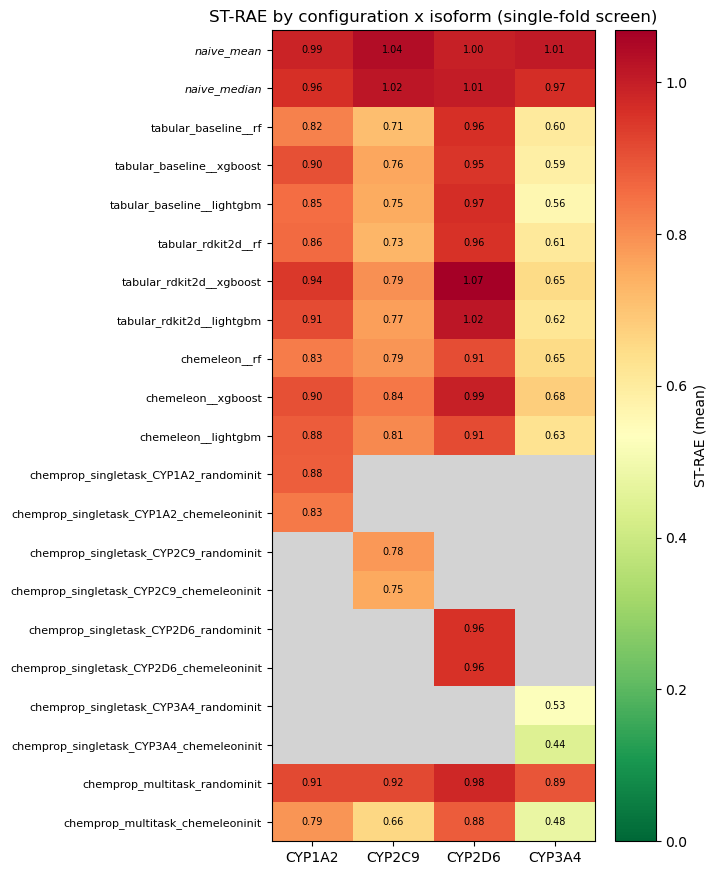

In [25]:
ENDPOINT_ORDER = list(REGRESSION_ENDPOINTS)
CONFIG_ORDER = ["naive_mean", "naive_median", *TABULAR_CONFIG_NAMES, *CHEMPROP_CONFIGS.keys()]

st_rae_mean = summary.pivot(index="config", columns="Endpoint", values="ST-RAE_mean").reindex(
    index=CONFIG_ORDER, columns=ENDPOINT_ORDER
)

fig, ax = plt.subplots(figsize=(7, 0.35 * len(CONFIG_ORDER) + 1.5))
cmap = plt.cm.RdYlGn_r.copy()
cmap.set_bad("lightgray")
masked = np.ma.masked_invalid(st_rae_mean.to_numpy())
im = ax.imshow(masked, cmap=cmap, aspect="auto", vmin=0)
ax.set_xticks(range(len(ENDPOINT_ORDER)))
ax.set_xticklabels([e.split("_")[0] for e in ENDPOINT_ORDER])
ax.set_yticks(range(len(CONFIG_ORDER)))
ax.set_yticklabels(CONFIG_ORDER, fontsize=8)
for i, name in enumerate(CONFIG_ORDER):
    if name.startswith("naive"):
        ax.get_yticklabels()[i].set_fontstyle("italic")
for i in range(len(CONFIG_ORDER)):
    for j in range(len(ENDPOINT_ORDER)):
        val = st_rae_mean.iloc[i, j]
        if np.isfinite(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, label="ST-RAE (mean)")
ax.set_title("ST-RAE by configuration x isoform (single-fold screen)")
fig.tight_layout()
plt.show()

**What this shows:** ST-RAE (lower/greener is better) for every configuration (rows,
naive baselines in italics) against every isoform (columns) on this single held-out
fold. Blank cells are single-task Chemprop models, which only ever produce a real
prediction for their own isoform. This is exactly the view meant to catch a per-isoform
collapse (e.g. a feature set or algorithm doing fine in aggregate but near-naive on
CYP2D6 specifically) that a macro-averaged number alone would hide.

*Single-task Chemprop configs don't appear in the plots below -- each only predicts one isoform, so a 4-isoform macro-average doesn't apply to them; see the heatmap above for their single-isoform values instead.*

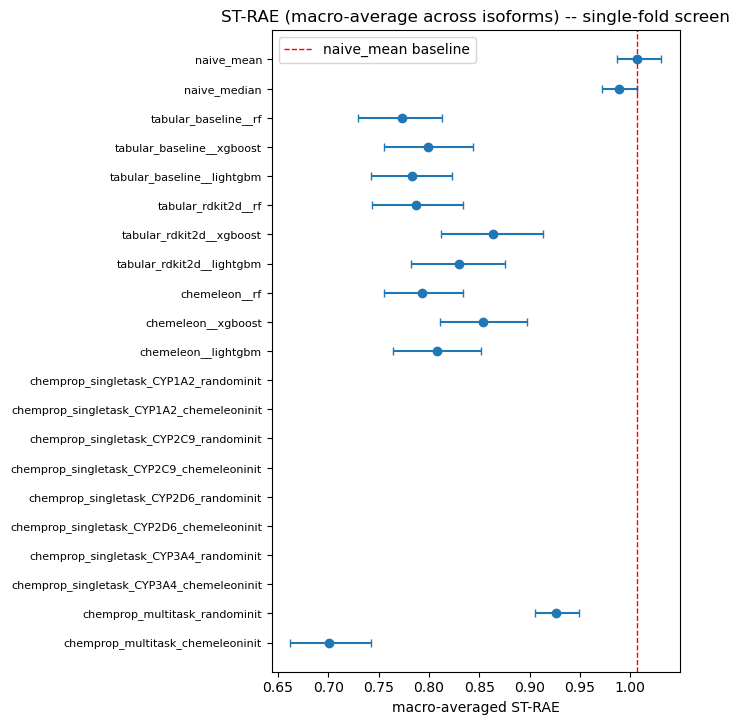

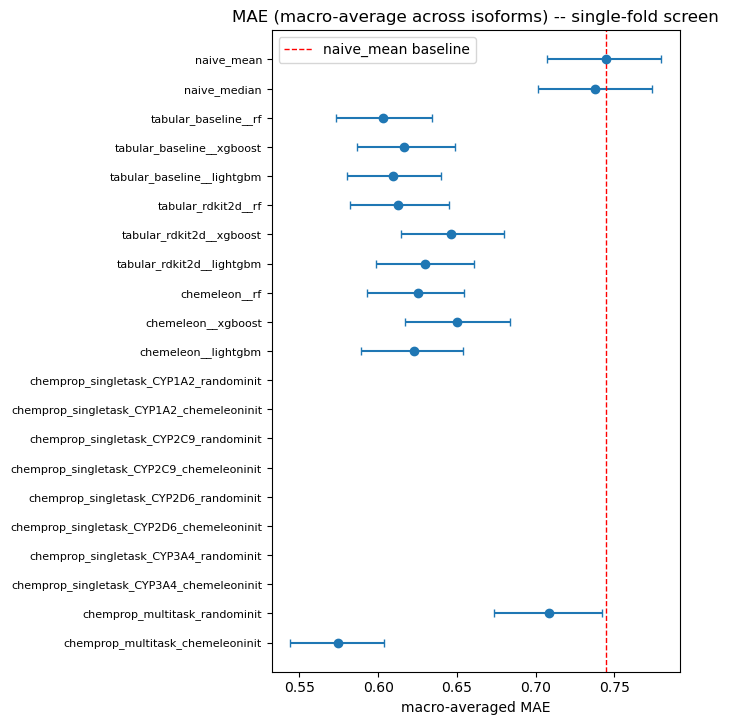

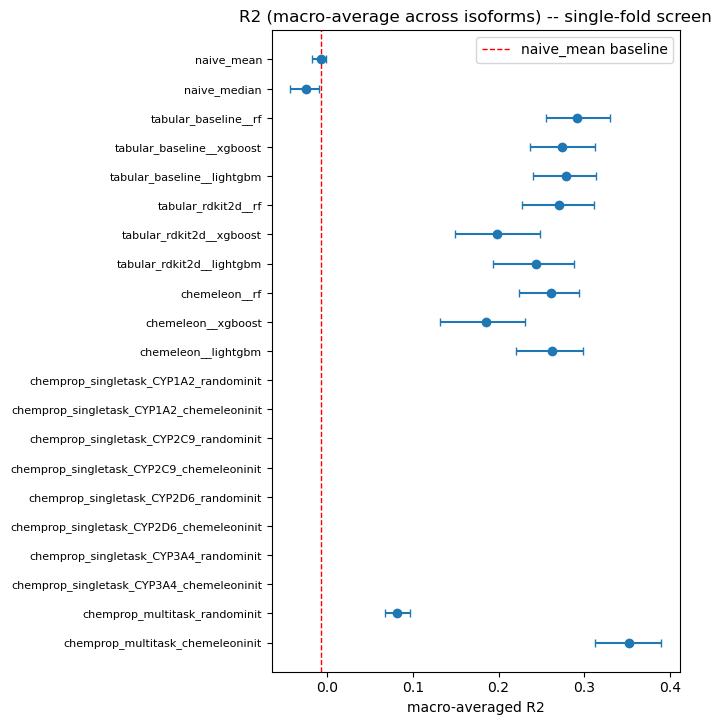

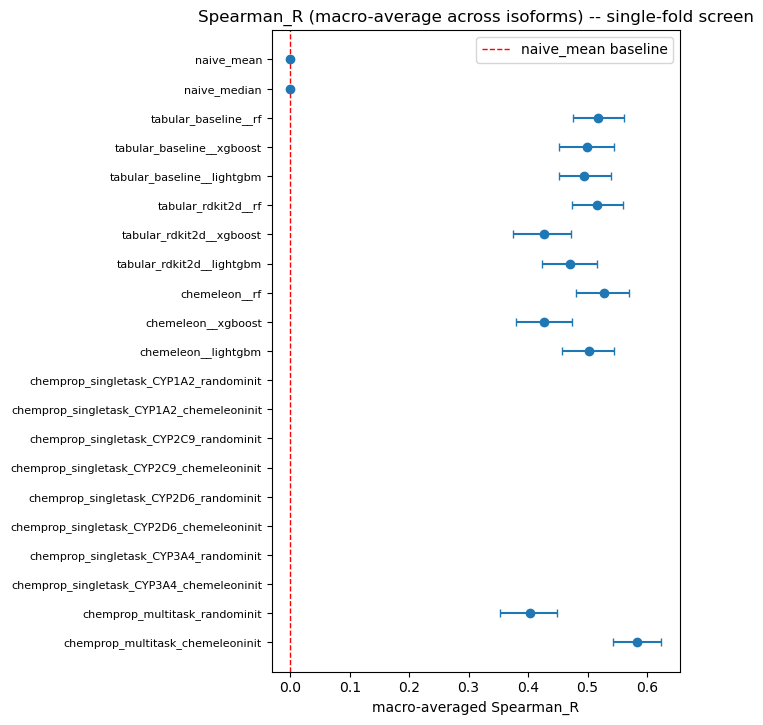

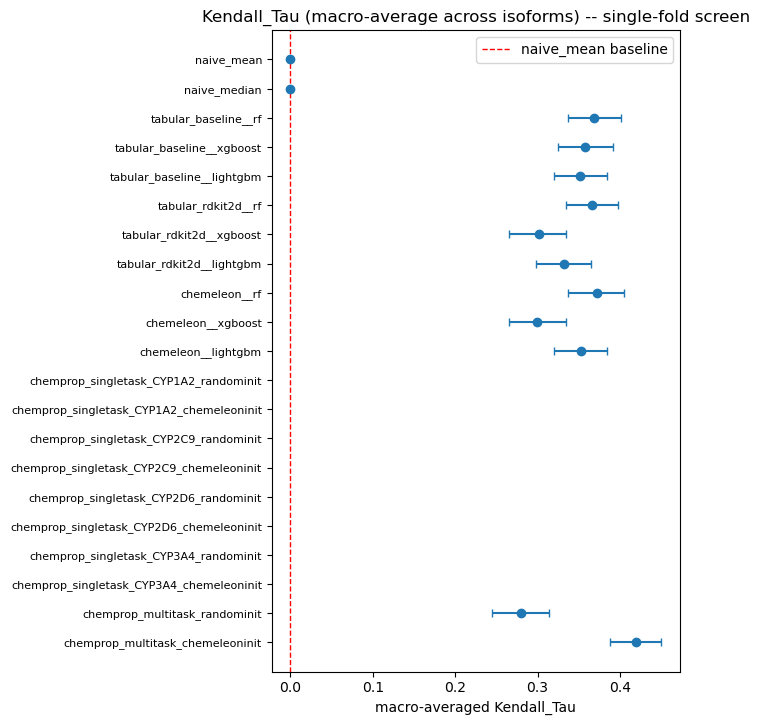

In [26]:
for metric_name, _ in ACTIVITY_METRICS:
    macro = summary[summary["Endpoint"] == "MA"].set_index("config").reindex(CONFIG_ORDER)
    naive_baseline = macro.loc["naive_mean", f"{metric_name}_mean"]

    fig, ax = plt.subplots(figsize=(7, max(4, 0.35 * len(CONFIG_ORDER))))
    y = np.arange(len(CONFIG_ORDER))
    means = macro[f"{metric_name}_mean"].to_numpy()
    lower_err = means - macro[f"{metric_name}_ci_low"].to_numpy()
    upper_err = macro[f"{metric_name}_ci_high"].to_numpy() - means
    valid = np.isfinite(means)
    ax.errorbar(means[valid], y[valid], xerr=[lower_err[valid], upper_err[valid]], fmt="o", capsize=3)
    ax.axvline(naive_baseline, color="red", linestyle="--", linewidth=1, label="naive_mean baseline")
    ax.set_yticks(y)
    ax.set_yticklabels(CONFIG_ORDER, fontsize=8)
    ax.invert_yaxis()  # naive_mean (first in CONFIG_ORDER) at the top, matching the heatmap above
    ax.set_xlabel(f"macro-averaged {metric_name}")
    ax.set_title(f"{metric_name} (macro-average across isoforms) -- single-fold screen")
    ax.legend()
    fig.tight_layout()
    plt.show()

**What these show:** macro-averaged point estimate + 95% bootstrap CI per configuration,
one plot per metric, with the naive-mean baseline drawn as a horizontal reference line
-- a configuration whose CI doesn't clear this line is, on this single fold, not yet
distinguishable from always predicting the training mean. Single-task Chemprop
configurations are omitted from these macro plots (a "macro-average" over one isoform
is just that isoform's own value; see the heatmap above for those). As stated at the
top: no promotion threshold for the 25-fold comparison is computed or suggested here --
that's deferred until these results exist and can be looked at directly.

In [27]:
import re


def parse_chemprop_log_timing(log_path: Path):
    if not log_path.exists():
        return {}, None
    text = log_path.read_text()
    per_model = {m: float(s) for m, s in re.findall(r"model (\S+) elapsed: ([\d.]+)s", text)}
    total_match = re.search(r"total script wall time: ([\d.]+)s", text)
    total_s = float(total_match.group(1)) if total_match else None
    return per_model, total_s


randominit_times, randominit_total = parse_chemprop_log_timing(REPO_ROOT / "logs" / "04a_chemprop_screen.log")
chemeleoninit_times, chemeleoninit_total = parse_chemprop_log_timing(REPO_ROOT / "logs" / "04a_chemprop_screen_chemeleon.log")

timing_table = pd.DataFrame({
    "randominit_seconds": pd.Series(randominit_times),
    "chemeleoninit_seconds": pd.Series(chemeleoninit_times),
})
timing_table["slowdown_x"] = timing_table["chemeleoninit_seconds"] / timing_table["randominit_seconds"]
if randominit_total and chemeleoninit_total:
    timing_table.loc["TOTAL"] = [randominit_total, chemeleoninit_total, chemeleoninit_total / randominit_total]
timing_table

,randominit_seconds,chemeleoninit_seconds,slowdown_x
singletask_CYP1A2,61.5,1743.4,28.347967
singletask_CYP2C9,43.5,1638.2,37.659770
singletask_CYP2D6,42.5,1556.1,36.614118
singletask_CYP3A4,120.7,4236.8,35.101906
multitask,73.2,6070.3,82.927596
TOTAL,344.0,15247.4,44.323837


**Random-init vs. CheMeleon-init -- the actual question this extra run answers.**
The table above gives real, measured training time per model on this same fold and
hardware; the heatmap and error-bar plots above pair each isoform's `_randominit` and
`_chemeleoninit` configs adjacently for a direct score comparison. Together they answer
the compute-budget question this addition exists to ask: does CheMeleon-init's real,
measured cost buy enough of a score improvement over random-init to justify it at the
full 25-fold scale, or not -- read the two side by side above rather than either number
alone.

**Still a single fold, not the 25-fold result.** The wall-clock times above are a
same-fold, same-hardware data point for the compute-budget conversation, not yet a
full-25-fold projection -- and the scores themselves carry the same single-fold caveat
as everything else in this notebook.

## Before finishing, check against CLAUDE.md

- **Never fetch/invent/approximate data:** no raw data was fetched or approximated.
  TabICLv2 (a model, not data) was installed with the user's sign-off to auto-download
  its checkpoint from Hugging Face, but turned out to need 36-50GB to run on this
  screen's context size -- more than this 36GB machine has -- confirmed via a clean
  MPS out-of-memory error and a silent CPU `SIGKILL`; forcing the Apple GPU instead
  segfaults outright. Raised with the user rather than silently substituting different
  hyperparameters to make it fit; the user chose to drop it from this run entirely
  (Section 3) rather than deviate from library defaults.
- **Seeds vary per fold, not shared globally; every seed logged:** this screen has only
  one fold by construction, so the per-fold-variation rule doesn't apply here (it
  applies to the real 25-fold comparison); `SEED = 42` is logged in Section 0 and
  recorded in every config's params JSON.
- **Splits/fingerprints through one shared module:** `assign_screen_split` lives in
  `src/features.py` and is called identically from this notebook and both Chemprop
  scripts (via `src/chemprop_screen.py`, factored out so the two scripts' shared
  orchestration code -- progress logging, the subprocess stdin fix, training-
  population construction -- lives in one place) -- cross-checked in Section 4.
- **Row counts logged before/after filtering:** Section 1's per-isoform counts table;
  `scripts/run_baseline_screen_chemprop.py` logs the same before/after its own
  single-task label filtering.
- **Every trained model result saved to disk before moving on:** each tabular config's
  predictions + params are written immediately after that config's 4 isoform fits
  (Section 3); Chemprop's script does the same per model.
- **No stacking un-tested changes:** 19 real configurations were run as one flat
  comparison, not as incremental tweaks to a single pipeline -- there was nothing to
  test incrementally here. The CheMeleon-init Chemprop addition itself was scoped
  tightly (no extra seeds, no hyperparameter variations) rather than folded into a
  broader re-run.
- **Modelling decisions not specified in the prompt were flagged, not silently
  picked:** TabICLv2's missing dependency + network-fetching checkpoint, its
  hardware-driven infeasibility once installed, the early-stopping patience/rounds
  values, and log2fc_pretrained's reframing out of this screen (Section 3) were all
  raised with the user before implementation (see conversation).
- **Test-set/leaderboard labels never used to pick or retrain:** `screen_test` here is
  an ordinary held-out *training* fold, not the real blinded leaderboard test set --
  the real test set is never loaded or touched anywhere in this notebook or the
  Chemprop script.
- **Markdown after every major output:** present after Sections 1-6's outputs above.